In [4]:
import duckdb
import pandas as pd

# Connect to database
conn = duckdb.connect(database=':memory:')

# Map files to views
conn.execute("""
CREATE VIEW customers AS
SELECT * FROM read_csv_auto('D:/Github projects/olist data/olist_customers_dataset.csv')
""")

conn.execute("""
CREATE VIEW orders AS
SELECT * FROM read_csv_auto('D:/Github projects/olist data/olist_orders_dataset.csv')
""")

conn.execute("""
CREATE VIEW items AS
SELECT * FROM read_csv_auto('D:/Github projects/olist data/olist_order_items_dataset.csv')
""")

# --- WRITE YOUR SQL BUSINESS QUERY BELOW ---
ba_query = """
SELECT
    c.customer_city,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(i.price), 2) AS total_revenue,
    ROUND(SUM(i.price) / COUNT(DISTINCT o.order_id), 2) AS average_order_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN items i ON o.order_id = i.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_city
ORDER BY total_revenue DESC
LIMIT 10;
"""

# Execute and fetch into Pandas
df_sales_analysis = conn.execute(ba_query).df()

# Display the results
print(" --- TOP 10 CITIES SALES ANALYSIS --- ")
print(df_sales_analysis)

 --- TOP 10 CITIES SALES ANALYSIS --- 
    customer_city  total_orders  total_revenue  average_order_value
0       sao paulo         15045     1859556.83               123.60
1  rio de janeiro          6601      955573.97               144.76
2  belo horizonte          2697      346039.04               128.31
3        brasilia          2071      295814.72               142.84
4        curitiba          1489      205999.33               138.35
5        campinas          1406      184657.87               131.34
6    porto alegre          1342      182319.55               135.86
7        salvador          1188      173273.05               145.85
8       guarulhos          1144      139008.19               121.51
9         niteroi           825      115890.26               140.47


C:\Users\HP\AppData\Local\Temp\ipykernel_21488\3118285705.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


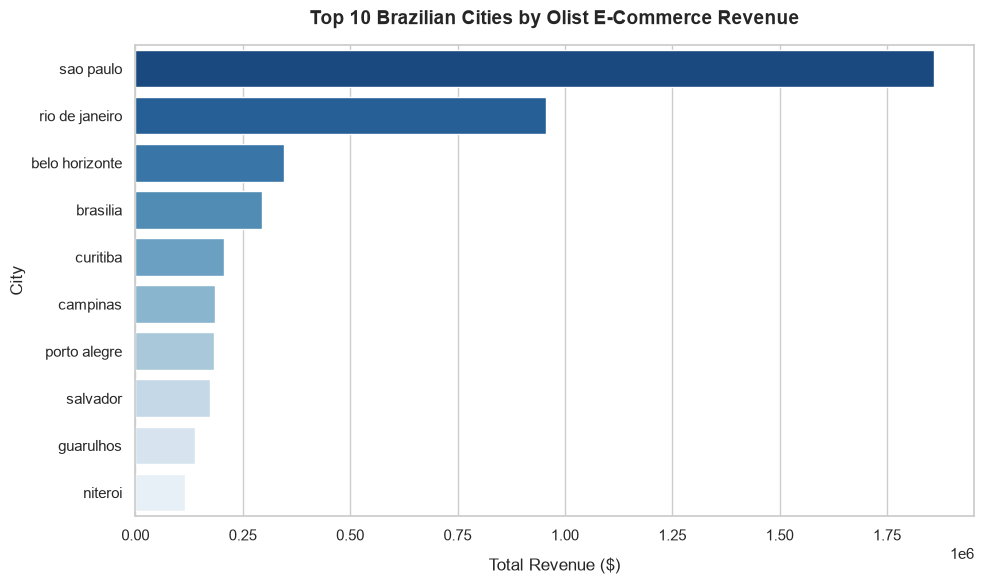

Chart successfully generated and saved as 'top_10_cities_revenue.png'!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Initialize a 10x6 inch plot window
plt.figure(figsize=(10, 6))

# Create the bar chart
ax = sns.barplot(
    data=df_sales_analysis,
    x='total_revenue',
    y='customer_city',
    palette='Blues_r' # Beautiful fading blue color palette
)

# Format the title and labels for business presentation
plt.title('Top 10 Brazilian Cities by Olist E-Commerce Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontsize=12, labelpad=10)
plt.ylabel('City', fontsize=12)

# Clean up layout and save the chart to your project folder
plt.tight_layout()
plt.savefig('top_10_cities_revenue.png', dpi=300)
plt.show()

print("Chart successfully generated and saved as 'top_10_cities_revenue.png'!")